In [383]:
import pandas as pd
import geopandas as gpd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn import datasets
from shapely import Point

In [382]:
from pathlib  import Path
data_path_raw = Path('../data/raw')

files = {'grid':'trentino-grid.geojson',
         'adm_reg':'ondata_confini_amministrativi_api_v2_it_20120101_unita-territoriali-sovracomunali_22_comuni.geo.json',
        'weather':'meteotrentino-weather-station-data.json',
        'precip':'precipitation-trentino.csv',
        'precip-avail':'precipitation-trentino-data-availability.csv',
        'SET-1':'SET-nov-2013.csv',
        'SET-2':'SET-dec-2013.csv',
        'SET-lines':'line.csv',
        'twitter':'social-pulse-trentino.gejson'}

In [184]:
power_names = ['lineset', 'date_time', 'power']
pow_nov_df = pd.read_csv(data_path_raw / files['SET-1'],names=power_names)
pow_dec_df = pd.read_csv(data_path_raw / files['SET-2'],names=power_names)
pow_pos_df = pd.read_csv(data_path_raw / files['SET-lines'])

In [185]:
# costruisco e concateno i dataframe con la potenza
lines_df = pd.concat([pow_nov_df, pow_dec_df], ignore_index=True)
lines_df = lines_df.sort_values(['lineset', 'date_time'])

date_time = pd.to_datetime(lines_df['date_time'])
date = date_time.dt.date
hour = date_time.dt.hour
lines_df['date'] = date
lines_df['hour'] = hour
lines_df = lines_df.drop(columns=['date_time'])

lines_df.head()

,lineset,power,date,hour
0,DG1000420,37.439999,2013-11-01,0
1,DG1000420,37.439999,2013-11-01,0
2,DG1000420,36.000000,2013-11-01,0
3,DG1000420,35.279999,2013-11-01,0
4,DG1000420,35.279999,2013-11-01,0


In [186]:
# dato che gli inquinanti atmosferici sono misurati su base oraria, medio anche la potenza su ciascuna ora. Per semplicità chiamo potenza ad una data ora la
# la potenza emessa dalle 00:00 di quell'ora alle 59:59 di quell'ora
lines_df = lines_df.groupby(['lineset', 'date', 'hour'])['power'].mean().reset_index()
lines_df.head()

,lineset,date,hour,power
0,DG1000420,2013-11-01,0,35.939999
1,DG1000420,2013-11-01,1,33.779998
2,DG1000420,2013-11-01,2,31.889998
3,DG1000420,2013-11-01,3,31.979998
4,DG1000420,2013-11-01,4,31.349998


In [187]:
# ogni linea elettrica distribuisce corrente elettrica su diverse celle. Mergiamo il df con la potenza per linea, con quello con il numero di ubicazioni 
# per cella a cui ogni linea fornisce energia. Assumendo un consumo uniforme per ubicazione, cerchiamo poi quanta potenza venga effettivamente consumata in
# ciascuna cella.

el_power_df = pd.merge(pow_pos_df,lines_df,left_on='LINESET',right_on='lineset',how='right')

# calcolo il totale di ubicazioni per ogni linea
tot_ub_df = el_power_df.groupby(['lineset', 'date', 'hour'])['NR_UBICAZIONI'].sum().reset_index().drop_duplicates(subset='lineset')
tot_ub_df = tot_ub_df.rename(columns={'NR_UBICAZIONI': 'tot_ub'})
el_power_df['tot_ub'] = el_power_df['lineset'].map(tot_ub_df.set_index('lineset')['tot_ub'])

el_power_df['power_square'] = el_power_df['power'] * el_power_df['NR_UBICAZIONI'] / el_power_df['tot_ub']
el_power_df = el_power_df.rename(columns={'SQUAREID': 'squareid'})
el_power_df.head()

,squareid,LINESET,NR_UBICAZIONI,lineset,date,hour,power,tot_ub,power_square
0,4037,DG1000420,2,DG1000420,2013-11-01,0,35.939999,2133,0.033699
1,4154,DG1000420,13,DG1000420,2013-11-01,0,35.939999,2133,0.219044
2,4155,DG1000420,20,DG1000420,2013-11-01,0,35.939999,2133,0.336990
3,4156,DG1000420,2,DG1000420,2013-11-01,0,35.939999,2133,0.033699
4,4269,DG1000420,1,DG1000420,2013-11-01,0,35.939999,2133,0.016850


In [188]:
# quello che interessa a me è di trovare la potenza media oraria per quandrato. Quindi raggruppo per quadrato e sommo
sq_power_df = el_power_df.groupby(['squareid', 'date', 'hour'])['power_square'].sum().reset_index()
sq_power_df.head()

,squareid,date,hour,power_square
0,155,2013-11-01,0,0.090551
1,155,2013-11-01,1,0.075594
2,155,2013-11-01,2,0.077797
3,155,2013-11-01,3,0.072870
4,155,2013-11-01,4,0.073739


In [189]:
# adesso voglio finalmente aggiungere la geometria facendo riferimento alla griglia

grid_df = gpd.read_file(data_path_raw / files['grid'])
sq_power_df['geometry'] = sq_power_df['squareid'].map(grid_df.set_index('cellId')['geometry'])
sq_power_df.head()

,squareid,date,hour,power_square,geometry
0,155,2013-11-01,0,0.090551,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
1,155,2013-11-01,1,0.075594,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
2,155,2013-11-01,2,0.077797,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
3,155,2013-11-01,3,0.072870,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."
4,155,2013-11-01,4,0.073739,"POLYGON ((10.91493 45.691, 10.92777 45.69079, ..."


In [ ]:
# vogliamo quindi capire quanto riescano effettivamente a muoversi gli inquinanti in atmosfera in modo da poter assegnare a ciascuna stazione un raggio entro
# cui l'eventuale emissione di inquinanti può essere effettivamente rilevata dalla stazione stessa.
# leggendo online, sembrano ci siano diversi modelli che possono descrivere questa dispersione degli inquinanti nella bassa atmosfera
# https://it.wikipedia.org/wiki/Modelli_di_dispersione_in_atmosfera
# studiare approfonditamente il fenomeno va ben oltre gli scopi di questo progetto. Assumiamo una descrizione approssimata e semplice della dispersione.

# da quanto ho capito, se viene trascurata la presenza del vento, i due principali vettori della dispersione sono il movimento browniano delle particelle in aria
# ed i moti turbolenti che si instaurano in presenza di gradienti termici. In generale sembra che il fenomeno browniano sia sostanzialmente trascurabile, portando
# a movimenti di solo qualche metro al giorno. Quello che fa la differenza sono invece i moti turbolenti, che possono trasportare l'inquinante anche a diverse
# centinaia di metri nel giro di qualche ora. 
# La distanza percorsa dalle particelle in questo secondo caso dipende dal coefficiente di diffusione turbolenta.

In [191]:
# introduciamo la posizione delle stazioni APPA
data_path_ext = Path('../data/external')

files_appa = {'dati_inq':'APPA_inquinamento_aria_Nov_Dec_2013.csv',
            'pos':'posizioni_stazioni_appa.csv',
            'dati_ext': 'APPA_extended.csv'}
appa_pos = pd.read_csv(data_path_ext / files_appa['pos'])
appa_pos['geometry'] = appa_pos['Posizione'].apply(lambda x:Point(float(x.split(",")[1]),float(x.split(",")[0])))

# cambio i nomi delle stazioni
data_names = ['Piana Rotaliana', 'Riva del Garda', 'Monte Gaza', 'Parco S. Chiara', 'Rovereto', 'Via Bolzano','A22 (Avio)', 'Borgo Valsugana']
appa_pos['station'] = data_names

appa_pos = appa_pos[['station', 'geometry']]
appa_pos

,station,geometry
0,Piana Rotaliana,POINT (11.11343 46.19683)
1,Riva del Garda,POINT (10.84448 45.89146)
2,Monte Gaza,POINT (10.95804 46.08253)
3,Parco S. Chiara,POINT (11.1262 46.06292)
4,Rovereto,POINT (11.03941 45.89243)
5,Via Bolzano,POINT (11.11022 46.10433)
6,A22 (Avio),POINT (10.97043 45.74215)
7,Borgo Valsugana,POINT (11.45389 46.05184)


In [457]:
# assegno le celle ad ogni stazione
# passiamo dalla notazione standard GPS alla notazione in metri
grid_df_crs = grid_df.set_crs("EPSG:4326").to_crs("EPSG:32632")

appa_pos = gpd.GeoDataFrame(data=appa_pos,geometry='geometry')
appa_pos_crs = appa_pos.set_crs("EPSG:4326").to_crs("EPSG:32632")

dfs = []
K = 1 # coefficiente di diffusione turbolenta - la nostra assunzione è abbastanza approssimativa

for h in range(24): # voglio l'impatto degli inquinanti entro un giorno
    radius = round(np.sqrt(6*K*h*3600) + 1) # distanza in m che assumiamo una particella possa percorrere in h ore
    # sommo 1 per sopperire a h = 0
    appa_buffer = appa_pos_crs
    appa_buffer[f"geometry_buffer_{radius}"] = appa_buffer.geometry.buffer(radius)
    appa_buffer = appa_buffer.set_geometry(f"geometry_buffer_{radius}")
    area_df = gpd.sjoin(appa_buffer,grid_df_crs,predicate="intersects",how="inner")
    area_df = pd.merge(left=area_df,right=sq_power_df,left_on='cellId',right_on='squareid',how='left')
    area_df = area_df.groupby(['station', 'geometry_x', f'geometry_buffer_{radius}', 'date', 'hour']).sum('power_square').reset_index()
    area_df = area_df.rename(columns={'geometry_x': 'geometry', 'power_square': f'power_area_{radius}'})

    area_df = area_df.sort_values(['station', 'date', 'hour'])
    area_df[f'{h}hb_power_area'] = area_df.groupby(['station'])[f'power_area_{radius}'].shift(h)
    area_df = area_df[['station', 'date', 'hour', f'{h}hb_power_area']]

    dfs.append(area_df)

final_power_df = dfs[0]

for df in dfs[1:]:
    final_power_df = pd.merge(final_power_df,df,on=['station', 'date', 'hour'],how='outer')

final_power_df = final_power_df.dropna(axis=0)

# sommo sulle diverse aree e mi tengo solo la colonna con l'area totale
power_cols = [a for a in final_power_df.columns if a.endswith('hb_power_area')]
final_power_df['tot_area_power'] = final_power_df[power_cols].sum(axis=1)
final_power_df = final_power_df[['station', 'date', 'hour', 'tot_area_power']]
final_power_df.head()

,station,date,hour,tot_area_power
23,A22 (Avio),2013-11-01,23.0,98.779135
24,A22 (Avio),2013-11-02,0.0,99.983828
25,A22 (Avio),2013-11-02,1.0,101.379504
26,A22 (Avio),2013-11-02,2.0,102.205106
27,A22 (Avio),2013-11-02,3.0,103.099904


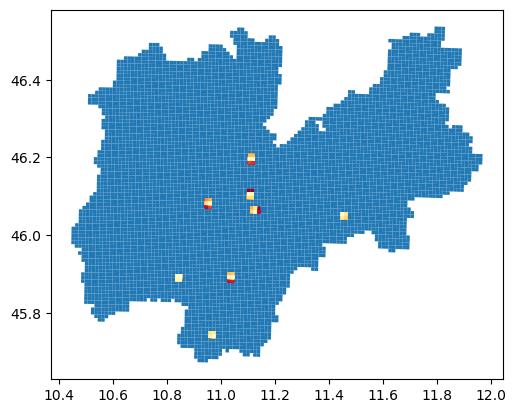

In [470]:
# le grandezze che abbiamo preso hanno senso? Gli inquinanti potrebbero muoversi di più?
# capiamo guardando sulla mappa

grid_df_crs = grid_df.set_crs("EPSG:4326").to_crs("EPSG:32632")
appa_pos_crs = appa_pos.set_crs("EPSG:4326").to_crs("EPSG:32632")

dfs = []
K = 1 # coefficiente di diffusione turbolenta - la nostra assunzione è abbastanza approssimativa

for h in range(24): # voglio l'impatto degli inquinanti entro un giorno
    radius = round(np.sqrt(6*K*h*3600) + 1) # distanza in m che assumiamo una particella possa percorrere in h ore
    # sommo 1 per sopperire a h = 0
    appa_buffer = appa_pos_crs
    appa_buffer[f"geometry_buffer_{radius}"] = appa_buffer.geometry.buffer(radius)
    appa_buffer = appa_buffer.set_geometry(f"geometry_buffer_{radius}")
    area_df = gpd.sjoin(appa_buffer,grid_df_crs,predicate="intersects",how="inner")
    area_df = area_df[['station', 'geometry', f'geometry_buffer_{radius}', 'cellId']]
    area_df = pd.merge(area_df,grid_df,on='cellId',how='left')
    area_df = gpd.GeoDataFrame(data=area_df,geometry='geometry_y')

    dfs.append(area_df)

cmap = plt.cm.YlOrRd

ax = grid_df.plot()
for h in range(23, -1, -1):
    dfs[h].plot(ax = ax,color=cmap(h / 24))

In [471]:
# confrontiamo con la mappa del comune per vedere effettivamente quanto stiamo prendendo

# importiamo innanzitutto il dataframe con i confini amministrativi
import json
from shapely.geometry import shape
with open(data_path_raw / files['adm_reg']) as f:
    admin_json = json.load(f)

admin_df = gpd.GeoDataFrame(admin_json['features'])
admin_df['geometry'] = admin_df['geometry'].apply(shape)
admin_df['municipality'] = admin_df['properties'].apply(lambda x: x['comune'])
admin_df = gpd.GeoDataFrame(admin_df,geometry='geometry')
admin_df.head()

,type,properties,geometry,municipality
0,Feature,"{'pkuid': 3467, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.23686 45.9545, 11.2373 45.95449, ...",Folgaria
1,Feature,"{'pkuid': 3468, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.19112 46.5037, 11.19183 46.50402,...",Fondo
2,Feature,"{'pkuid': 3469, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.21929 46.12242, 11.22091 46.12267...",Fornace
3,Feature,"{'pkuid': 3470, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.30778 46.09674, 11.31344 46.09521...",Frassilongo
4,Feature,"{'pkuid': 3471, 'cod_rip': 2, 'cod_reg': 4, 'c...","POLYGON ((11.06351 46.02184, 11.07263 46.02202...",Garniga Terme


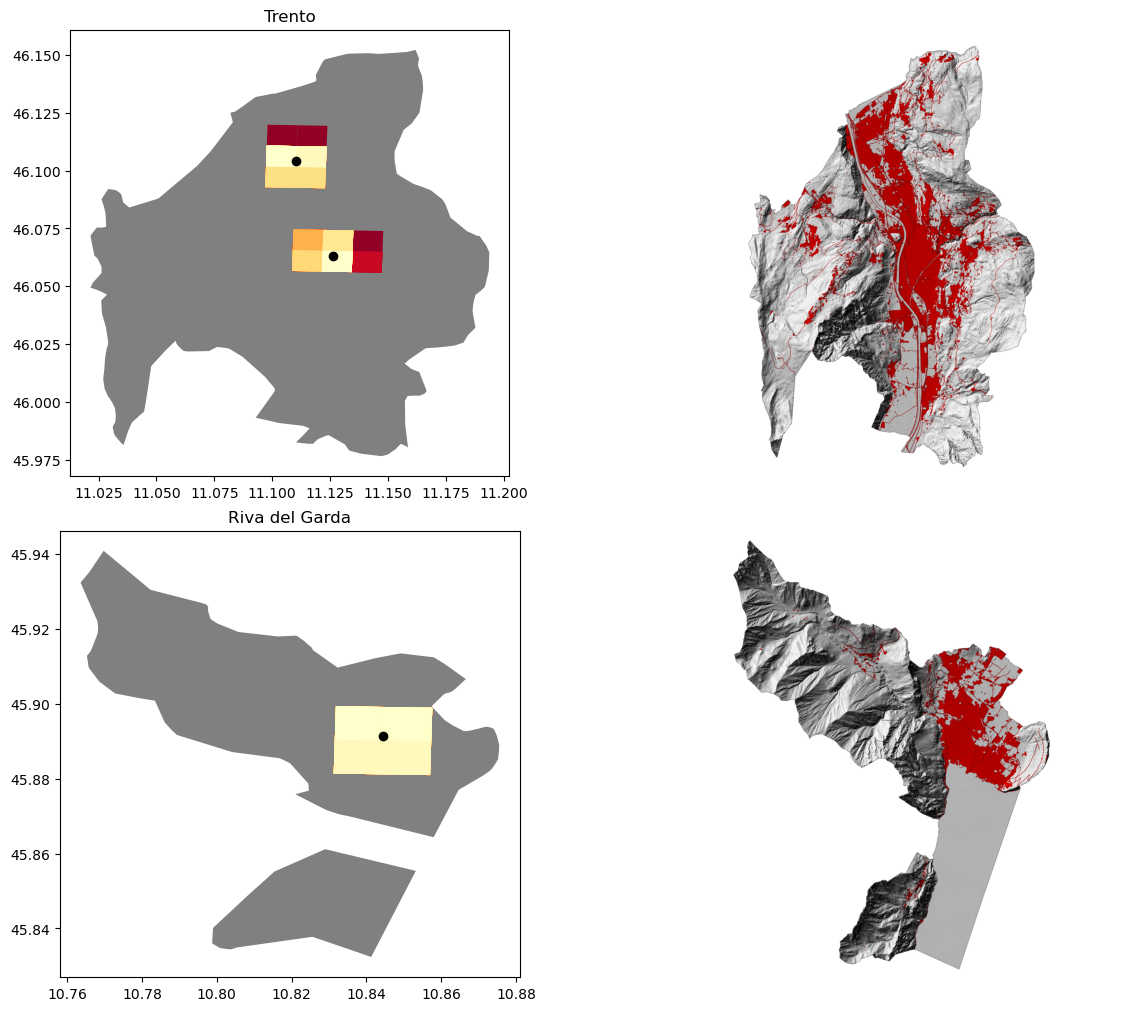

In [472]:
import matplotlib.image as mpimg

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Trento
ax = axes[0][0]
admin_df[admin_df['municipality'] == 'Trento'].plot(ax=ax,color='gray')
for h in range(23, -1, -1):
    dfs[h][(dfs[h]['station'] == 'Parco S. Chiara') | (dfs[h]['station'] == 'Via Bolzano')].plot(ax=ax,color=cmap(h / 24))
appa_pos[(appa_pos['station'] == 'Parco S. Chiara') | (appa_pos['station'] == 'Via Bolzano')].plot(ax=ax,color='black')
ax.set_title("Trento")

img = mpimg.imread("../data/images/Trento.png")
axes[0][1].imshow(img)
axes[0][1].axis("off")

# Riva del Garda
ax = axes[1][0]
admin_df[admin_df['municipality'] == 'Riva del Garda'].plot(ax=ax,color='gray')
for h in range(23, -1, -1):
    dfs[h][dfs[h]['station'] == 'Riva del Garda'].plot(ax=ax,color=cmap(h / 24))
appa_pos[appa_pos['station'] == 'Riva del Garda'].plot(ax=ax,color='black')
ax.set_title("Riva del Garda")

img = mpimg.imread("../data/images/Riva del Garda.png")
axes[1][1].imshow(img)
axes[1][1].axis("off")

plt.show()

In [302]:
encoded = pd.get_dummies(final_power_df,columns=['station'],dtype=int)
encoded.head()

,date,hour,tot_area_power,station_A22 (Avio),station_Borgo Valsugana,station_Monte Gaza,station_Parco S. Chiara,station_Rovereto,station_Via Bolzano
23,2013-11-01,23.0,98.779135,1,0,0,0,0,0
24,2013-11-02,0.0,99.983828,1,0,0,0,0,0
25,2013-11-02,1.0,101.379504,1,0,0,0,0,0
26,2013-11-02,2.0,102.205106,1,0,0,0,0,0
27,2013-11-02,3.0,103.099904,1,0,0,0,0,0
